In [1]:
%%capture
!pip install facenet-pytorch

## Libraries

In [2]:
import sys
sys.path.append('/home/pj00/projects/Github/small_face_recognition_trcking/utils')

In [3]:
import numpy as np
import cv2
import time
import torch
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training

from utils import extract_face, take_picture, detect_crop_image

%matplotlib inline
import matplotlib.pyplot as plt

/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

## Take image using camera OR Upload image

In [4]:
data_path = '/home/pj00/projects/Github/small_face_recognition_trcking/Data/finetuning_data'

In [5]:
frame = extract_face(save_path=data_path)

[ WARN:0@2.146] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


Photo taken!


In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [7]:
mtcnn = MTCNN(
    image_size=112,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=device
)


In [42]:
transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

In [43]:
images= detect_crop_image(frame=frame, model=mtcnn, transform=transform, device=device)

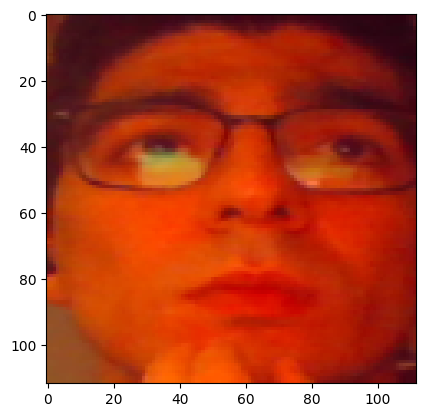

In [44]:
plt.imshow(images[0].detach().cpu().permute(1,2,0))

In [18]:
image= Image.fromarray(frame)

In [21]:
boxes, _ = mtcnn.detect(image)
boxes = boxes.astype(int)

In [23]:
for box in boxes:
    cropped_image = image.crop(box)

In [38]:
transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

In [39]:
i = transform(cropped_image)

In [41]:
torch.min(i)

tensor(-2.0357)

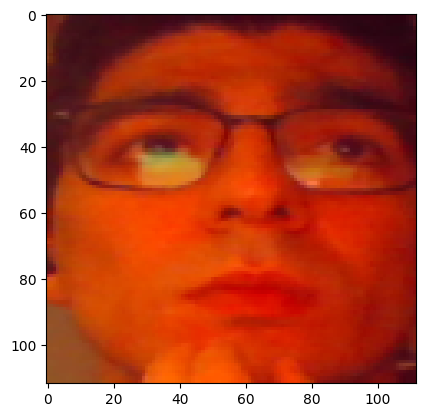

In [35]:
plt.imshow(i.detach().cpu().permute(1,2,0))